# UD04 · Cuaderno de cinemática (CE 4a, 4b)

**Duración estimada:** 2 h (trabajo autónomo TA1) · **Objetivo:** resolver la cinemática directa e inversa de un manipulador plano 2R y analizar sus problemas (soluciones múltiples, espacio de trabajo, singularidades).

> Actividad 1 de la [UD04](../actividades/act1_cinematica.md). No necesita hardware.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Cinemática directa (FK)

`x = l1·cos(t1) + l2·cos(t1+t2)` · `y = l1·sin(t1) + l2·sin(t1+t2)`

In [2]:
L1, L2 = 150.0, 120.0   # mm

def fk_2r(t1, t2, l1=L1, l2=L2):
    x = l1 * math.cos(t1) + l2 * math.cos(t1 + t2)
    y = l1 * math.sin(t1) + l2 * math.sin(t1 + t2)
    return x, y

for (t1, t2) in [(0, 0), (math.pi/2, 0), (0, math.pi/2), (math.pi/4, math.pi/4)]:
    x, y = fk_2r(t1, t2)
    print(f"t1={math.degrees(t1):5.0f} t2={math.degrees(t2):5.0f} -> x={x:7.1f} y={y:7.1f}")

t1=    0 t2=    0 -> x=  270.0 y=    0.0
t1=   90 t2=    0 -> x=    0.0 y=  270.0
t1=    0 t2=   90 -> x=  150.0 y=  120.0
t1=   45 t2=   45 -> x=  106.1 y=  226.1


## 2. Cinemática inversa (IK): las dos soluciones (codo arriba / codo abajo)

In [3]:
def ik_2r(x, y, l1=L1, l2=L2):
    """Devuelve las dos soluciones (t1, t2) o lanza error si el punto no es alcanzable."""
    d2 = x*x + y*y
    cos_t2 = (d2 - l1*l1 - l2*l2) / (2*l1*l2)
    if abs(cos_t2) > 1:
        raise ValueError("punto fuera del alcance")
    t2a = math.acos(cos_t2)
    t2b = -t2a
    sols = []
    for t2 in (t2a, t2b):
        t1 = math.atan2(y, x) - math.atan2(l2*math.sin(t2), l1 + l2*math.cos(t2))
        sols.append((t1, t2))
    return sols

for (t1, t2) in ik_2r(200, 100):
    x, y = fk_2r(t1, t2)
    print(f"t1={math.degrees(t1):7.1f} t2={math.degrees(t2):7.1f} -> comprobacion x={x:6.1f} y={y:6.1f}")

t1=   -3.4 t2=   68.7 -> comprobacion x= 200.0 y= 100.0
t1=   56.6 t2=  -68.7 -> comprobacion x= 200.0 y= 100.0


## 3. Espacio de trabajo

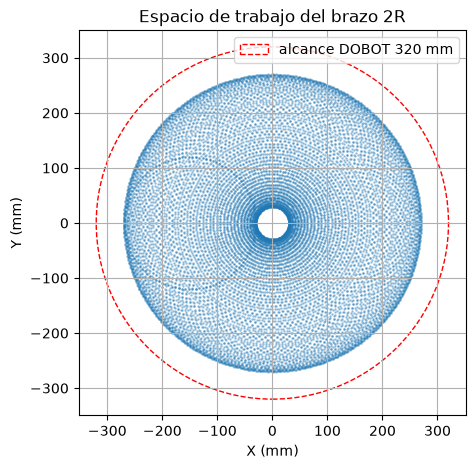

In [4]:
xs, ys = [], []
for t1 in np.linspace(-math.pi, math.pi, 120):
    for t2 in np.linspace(-math.pi, math.pi, 120):
        x, y = fk_2r(t1, t2)
        xs.append(x); ys.append(y)

plt.figure(figsize=(5, 5))
plt.scatter(xs, ys, s=1, alpha=0.3)
plt.gca().add_patch(plt.Circle((0, 0), 320, fill=False, ls="--", color="red", label="alcance DOBOT 320 mm"))
plt.axis("equal"); plt.grid(True); plt.legend(); plt.title("Espacio de trabajo del brazo 2R")
plt.xlabel("X (mm)"); plt.ylabel("Y (mm)"); plt.show()

## 4. Singularidad

Con `t2 = 0` el brazo está **totalmente estirado**: es una **singularidad**. Prueba a pedir por IK un punto muy cercano al límite `l1 + l2` y observa cómo `t2` se acerca a 0 y la solución se vuelve muy sensible.

In [5]:
x, y = ik_2r(269.9, 0)[0]
print("t2 (grados) cerca del limite:", round(math.degrees(y), 3))

t2 (grados) cerca del limite: 3.138


## Entregable (Actividad 1)

- Comprueba los resultados de la parte A (a mano) con este cuaderno.
- Añade una **conclusión de 3 líneas**: qué problemas de cinemática has encontrado y cómo se resuelven (CE 4a + 4b).